# Congressional Trading Risk Intelligence
## 04 — Ethics & Compliance Review Prioritization Model

This notebook builds a transparent **review-prioritization model** from congressional securities-disclosure data.

The model is designed to answer a narrow compliance-operations question:

> **Which disclosure profiles may warrant earlier human review based on observable data characteristics?**

It is **not** a misconduct, insider-trading, corruption, or ethics-violation model.

### Model dimensions

The prototype combines four explainable indicators:

1. **Disclosure timing** — frequency and extent of transaction-to-disclosure delays.
2. **Transaction frequency** — relative volume of disclosed transactions.
3. **Transaction magnitude** — approximate disclosed value using range midpoints.
4. **Portfolio concentration** — concentration of disclosed activity in the most-used sector.

Each component is normalized to a 0–100 scale and combined into a transparent composite score.


## 1. Import libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


## 2. Load cleaned disclosure data

In [2]:
DATA_PATH = Path("../data/processed/us_congress_trades_clean.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["transaction_date", "disclosure_date"]
)

df["disclosure_lag_days"] = (
    df["disclosure_date"] - df["transaction_date"]
).dt.days

print(f"Transactions: {len(df):,}")
print(f"Unique lawmakers: {df['representative'].nunique():,}")
df.head()


Transactions: 16,616
Unique lawmakers: 196


,disclosure_year,disclosure_date,transaction_date,owner,ticker,asset_description,type,amount,representative,district,state,ptr_link,cap_gains_over_200_usd,industry,sector,party,amount_min,amount_max,amount_midpoint,disclosure_lag_days
0,2021,2021-10-04,2021-09-27,joint,BP,BP plc,purchase,"$1,001 - $15,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Integrated oil Companies,Energy,Republican,1001.0,15000.0,8000.5,7.0
1,2021,2021-10-04,2021-09-13,joint,XOM,Exxon Mobil Corporation,purchase,"$1,001 - $15,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Integrated oil Companies,Energy,Republican,1001.0,15000.0,8000.5,21.0
2,2021,2021-10-04,2021-09-10,joint,ILPT,Industrial Logistics Properties Trust - Common Shares of Beneficial Interest,purchase,"$15,001 - $50,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Real Estate Investment Trusts,Real Estate,Republican,15001.0,50000.0,32500.5,24.0
3,2021,2021-10-04,2021-09-28,joint,PM,Phillip Morris International Inc,purchase,"$15,001 - $50,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Farming/Seeds/Milling,Consumer Non-Durables,Republican,15001.0,50000.0,32500.5,6.0
4,2021,2021-10-04,2021-09-17,self,BLK,BlackRock Inc,sale_partial,"$1,001 - $15,000",Alan S. Lowenthal,CA47,CA,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019570.pdf,False,Investment Bankers/Brokers/Service,Finance,Democrat,1001.0,15000.0,8000.5,17.0


## 3. Create lawmaker-level features

The model aggregates transaction records to the lawmaker level.

For disclosure timing, only non-negative lags are used. Records over 45 days are treated as **review flags**, consistent with Notebook 03's screening methodology.


In [3]:
df["valid_lag"] = df["disclosure_lag_days"].where(df["disclosure_lag_days"] >= 0)
df["over_45_flag"] = (df["disclosure_lag_days"] > 45).astype(int)

base_features = (
    df.groupby("representative")
    .agg(
        Transaction_Count=("representative", "size"),
        Potentially_Late_Count=("over_45_flag", "sum"),
        Median_Disclosure_Lag=("valid_lag", "median"),
        Maximum_Disclosure_Lag=("valid_lag", "max"),
        Estimated_Midpoint_Total=("amount_midpoint", "sum"),
        Party=("party", "first"),
        State=("state", "first")
    )
    .reset_index()
)

base_features["Potentially_Late_Rate"] = (
    base_features["Potentially_Late_Count"] /
    base_features["Transaction_Count"]
)

base_features.head()


,representative,Transaction_Count,Potentially_Late_Count,Median_Disclosure_Lag,Maximum_Disclosure_Lag,Estimated_Midpoint_Total,Party,State,Potentially_Late_Rate
0,Abigail Spanberger,4,0,2.5,21.0,32002.0,Democrat,VA,0.000000
1,Ada Norah Henriquez,4,0,22.0,22.0,32002.0,None,PR,0.000000
2,Adam B. Schiff,4,0,6.5,8.0,81002.0,Democrat,CA,0.000000
3,Adam Kinzinger,24,1,26.0,47.0,192012.0,Republican,IL,0.041667
4,Adrian Smith,1,0,22.0,22.0,3000000.5,Republican,NE,0.000000


## 4. Calculate sector concentration

In [4]:
sector_activity = (
    df.dropna(subset=["sector"])
    .groupby(["representative", "sector"])
    .size()
    .rename("Sector_Transactions")
    .reset_index()
)

largest_sector = (
    sector_activity.groupby("representative")["Sector_Transactions"]
    .max()
    .rename("Largest_Sector_Count")
    .reset_index()
)

base_features = base_features.merge(
    largest_sector,
    on="representative",
    how="left"
)

base_features["Largest_Sector_Count"] = (
    base_features["Largest_Sector_Count"].fillna(0)
)

base_features["Sector_Concentration"] = (
    base_features["Largest_Sector_Count"] /
    base_features["Transaction_Count"]
)

base_features[
    ["representative", "Transaction_Count", "Sector_Concentration"]
].head()


,representative,Transaction_Count,Sector_Concentration
0,Abigail Spanberger,4,0.750
1,Ada Norah Henriquez,4,0.500
2,Adam B. Schiff,4,0.500
3,Adam Kinzinger,24,0.375
4,Adrian Smith,1,0.000


## 5. Normalize model components

Percentile ranks are used rather than raw values because congressional trading activity is highly skewed. This prevents a few extreme observations from dominating the entire model.

A higher component score means **higher review priority on that dimension**, not higher probability of wrongdoing.


In [5]:
base_features["Timing_Component"] = (
    base_features["Potentially_Late_Rate"].rank(pct=True) * 100
)

base_features["Frequency_Component"] = (
    base_features["Transaction_Count"].rank(pct=True) * 100
)

base_features["Magnitude_Component"] = (
    base_features["Estimated_Midpoint_Total"].rank(pct=True) * 100
)

base_features["Concentration_Component"] = (
    base_features["Sector_Concentration"].rank(pct=True) * 100
)

base_features[
    [
        "representative",
        "Timing_Component",
        "Frequency_Component",
        "Magnitude_Component",
        "Concentration_Component"
    ]
].head()


,representative,Timing_Component,Frequency_Component,Magnitude_Component,Concentration_Component
0,Abigail Spanberger,21.173469,26.785714,11.224490,91.326531
1,Ada Norah Henriquez,21.173469,26.785714,11.224490,81.887755
2,Adam B. Schiff,21.173469,26.785714,24.744898,81.887755
3,Adam Kinzinger,48.979592,57.908163,37.244898,71.938776
4,Adrian Smith,21.173469,5.867347,79.081633,8.928571


## 6. Composite Compliance Review Score

Prototype weights:

- **40% Disclosure Timing**
- **25% Transaction Frequency**
- **20% Estimated Transaction Magnitude**
- **15% Sector Concentration**

Disclosure timing receives the largest weight because this project is framed primarily as a financial-disclosure compliance tool.

The weights are analytical design choices, not statutory or official congressional ethics weights.


In [6]:
WEIGHTS = {
    "Timing_Component": 0.40,
    "Frequency_Component": 0.25,
    "Magnitude_Component": 0.20,
    "Concentration_Component": 0.15
}

base_features["Compliance_Review_Score"] = (
    base_features["Timing_Component"] * WEIGHTS["Timing_Component"] +
    base_features["Frequency_Component"] * WEIGHTS["Frequency_Component"] +
    base_features["Magnitude_Component"] * WEIGHTS["Magnitude_Component"] +
    base_features["Concentration_Component"] * WEIGHTS["Concentration_Component"]
).round(1)

base_features["Compliance_Review_Score"].describe()


count    196.000000
mean      50.257143
std       17.514407
min       11.800000
25%       35.425000
50%       53.100000
75%       64.425000
max       82.100000
Name: Compliance_Review_Score, dtype: float64

## 7. Assign review-priority bands

In [7]:
def review_band(score):
    if score < 40:
        return "Routine"
    if score < 60:
        return "Monitor"
    if score < 75:
        return "Review"
    return "Priority Review"

base_features["Review_Priority"] = (
    base_features["Compliance_Review_Score"].apply(review_band)
)

base_features["Review_Priority"].value_counts()


Review_Priority
Monitor            66
Review             61
Routine            59
Priority Review    10
Name: count, dtype: int64

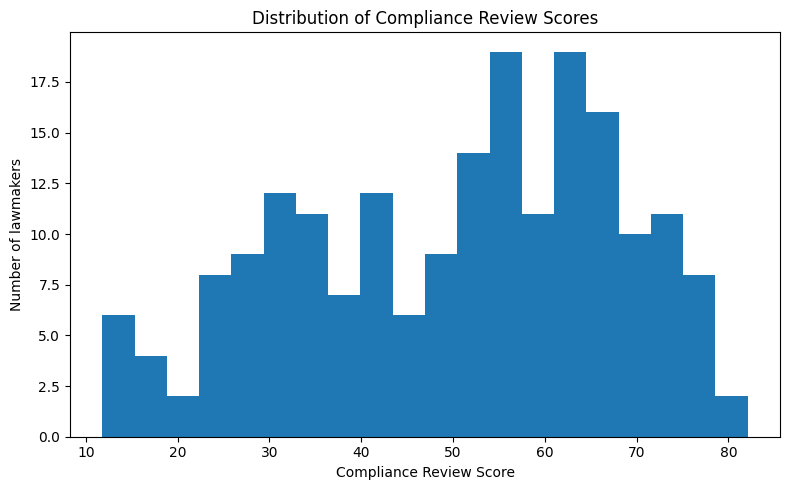

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(base_features["Compliance_Review_Score"], bins=20)
plt.title("Distribution of Compliance Review Scores")
plt.xlabel("Compliance Review Score")
plt.ylabel("Number of lawmakers")
plt.tight_layout()
plt.show()


## 8. Highest-priority profiles

The table below is a **workflow-prioritization output**. It identifies profiles that score highly under the prototype's chosen indicators and weights.

It does not rank lawmakers by ethics, integrity, legality, or likelihood of misconduct.


In [9]:
review_table = (
    base_features[
        [
            "representative",
            "Party",
            "State",
            "Transaction_Count",
            "Potentially_Late_Count",
            "Potentially_Late_Rate",
            "Estimated_Midpoint_Total",
            "Sector_Concentration",
            "Timing_Component",
            "Frequency_Component",
            "Magnitude_Component",
            "Concentration_Component",
            "Compliance_Review_Score",
            "Review_Priority"
        ]
    ]
    .sort_values("Compliance_Review_Score", ascending=False)
)

review_table.head(15)


,representative,Party,State,Transaction_Count,Potentially_Late_Count,Potentially_Late_Rate,Estimated_Midpoint_Total,Sector_Concentration,Timing_Component,Frequency_Component,Magnitude_Component,Concentration_Component,Compliance_Review_Score,Review_Priority
51,Donna Shalala,Democrat,FL,566,558,0.985866,5681783.0,0.113074,91.836735,96.938776,84.693878,28.061224,82.1,Priority Review
182,Tom Malinowski,Democrat,NJ,125,95,0.760000,2207562.5,0.296000,89.795918,83.673469,73.469388,64.285714,81.2,Priority Review
159,Sara Jacobs,Democrat,CA,64,51,0.796875,7413032.0,0.171875,90.306122,74.489796,89.795918,37.244898,78.3,Priority Review
129,Michael T. McCaul,Republican,TX,391,172,0.439898,33132195.5,0.122762,77.551020,93.367347,96.938776,28.571429,78.0,Priority Review
17,Blake Moore,Republican,UT,99,71,0.717172,926049.5,0.272727,89.285714,80.102041,58.673469,60.714286,76.6,Priority Review
105,Kathy Manning,Democrat,NC,250,48,0.192000,10433124.5,0.324000,64.285714,89.795918,91.836735,66.326531,76.5,Priority Review
23,Carol Devine Miller,Republican,WV,87,58,0.666667,2406544.0,0.218391,85.459184,78.061224,76.020408,50.510204,76.5,Priority Review
28,Chris Jacobs,Republican,NY,298,85,0.285235,6306149.0,0.194631,71.938776,92.857143,87.244898,44.897959,76.2,Priority Review
30,Cynthia Axne,Democrat,IA,181,124,0.685083,1448090.5,0.187845,87.244898,87.244898,65.816327,42.346939,76.2,Priority Review
118,Marie Newman,Democrat,IL,286,67,0.234266,6049143.0,0.244755,66.836735,92.346939,85.714286,54.081633,75.1,Priority Review


## 9. Explain an individual score

In [10]:
example = review_table.iloc[0]

explanation = pd.DataFrame({
    "Component": [
        "Disclosure timing",
        "Transaction frequency",
        "Estimated magnitude",
        "Sector concentration"
    ],
    "Component_Score": [
        example["Timing_Component"],
        example["Frequency_Component"],
        example["Magnitude_Component"],
        example["Concentration_Component"]
    ],
    "Weight": [0.40, 0.25, 0.20, 0.15]
})

explanation["Weighted_Contribution"] = (
    explanation["Component_Score"] * explanation["Weight"]
).round(1)

print(f"Example profile: {example['representative']}")
print(f"Composite score: {example['Compliance_Review_Score']}")
print(f"Review priority: {example['Review_Priority']}")
explanation


Example profile: Donna Shalala
Composite score: 82.1
Review priority: Priority Review


,Component,Component_Score,Weight,Weighted_Contribution
0,Disclosure timing,91.836735,0.40,36.7
1,Transaction frequency,96.938776,0.25,24.2
2,Estimated magnitude,84.693878,0.20,16.9
3,Sector concentration,28.061224,0.15,4.2


This decomposition makes the score auditable: an analyst can see exactly which features increased a profile's review priority.


## 10. Sensitivity test

A responsible risk model should not hide how much its rankings depend on subjective weights.

The alternative specification below reduces the disclosure-timing weight and increases transaction-frequency weight.


In [11]:
ALT_WEIGHTS = {
    "Timing_Component": 0.30,
    "Frequency_Component": 0.35,
    "Magnitude_Component": 0.20,
    "Concentration_Component": 0.15
}

base_features["Alternative_Score"] = (
    base_features["Timing_Component"] * ALT_WEIGHTS["Timing_Component"] +
    base_features["Frequency_Component"] * ALT_WEIGHTS["Frequency_Component"] +
    base_features["Magnitude_Component"] * ALT_WEIGHTS["Magnitude_Component"] +
    base_features["Concentration_Component"] * ALT_WEIGHTS["Concentration_Component"]
).round(1)

sensitivity = base_features[
    [
        "representative",
        "Compliance_Review_Score",
        "Alternative_Score"
    ]
].copy()

sensitivity["Score_Change"] = (
    sensitivity["Alternative_Score"] -
    sensitivity["Compliance_Review_Score"]
).round(1)

sensitivity["Absolute_Change"] = sensitivity["Score_Change"].abs()

sensitivity.sort_values("Absolute_Change", ascending=False).head(15)


,representative,Compliance_Review_Score,Alternative_Score,Score_Change,Absolute_Change
87,Jim Hagedorn,55.0,45.9,-9.1,9.1
70,Grace Meng,55.0,45.9,-9.1,9.1
33,Dan Newhouse,41.8,32.8,-9.0,9.0
14,Bill Huizenga,41.8,32.8,-9.0,9.0
142,Patrick T. McHenry,57.3,48.3,-9.0,9.0
157,Russ Fulcher,41.8,32.8,-9.0,9.0
176,Teresa Leger Fernandez,44.2,35.2,-9.0,9.0
168,Steve Chabot,56.1,48.0,-8.1,8.1
83,Jamie Raskin,67.4,59.3,-8.1,8.1
93,John P. Sarbanes,45.1,37.1,-8.0,8.0


## 11. Export review-prioritization scores

In [12]:
OUTPUT_PATH = Path("../data/processed/congressional_compliance_review_scores.csv")

review_table.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Profiles scored: {len(review_table):,}")


Saved: ../data/processed/congressional_compliance_review_scores.csv
Profiles scored: 196


## Model limitations and responsible use

This prototype deliberately separates **screening** from **legal judgment**.

### Limitations

- The dataset may not contain every congressional transaction or subsequent amendment.
- Disclosure date does not necessarily establish the precise legal filing circumstances.
- The filer-notification date required to evaluate the separate 30-day timing rule is unavailable.
- Transaction amounts are disclosed as ranges; midpoint values are estimates.
- Trading frequency may reflect portfolio-management style rather than compliance risk.
- Sector concentration is not inherently problematic.
- Model weights and priority bands are analytical design choices.
- Public disclosure data alone cannot establish insider trading, intent, corruption, or an ethics violation.

### Appropriate use

The score can be used to **prioritize records for human review**, identify unusual patterns, and demonstrate how transparent compliance analytics can support legal workflows.

It should never be used as an automated determination of misconduct.

## Portfolio takeaway

Across four notebooks, this project demonstrates an end-to-end legal-tech workflow:

**Raw disclosure data → data cleaning → exploratory intelligence → legal-rule screening → explainable compliance review prioritization**

The central design principle is that analytics can help legal teams decide **where to look**, while legal conclusions remain grounded in law, evidence, context, and human review.
